Step 1: Data Preparation & Exploration

Data shape: (1000, 19)
Date range: 2023-01-01 00:00:00 → 2023-01-01 16:39:00

Target statistics (performance_score):
count    1000.000000
mean        0.496677
std         0.110039
min         0.183052
25%         0.419186
50%         0.495015
75%         0.569606
max         0.808333
Name: performance_score, dtype: float64


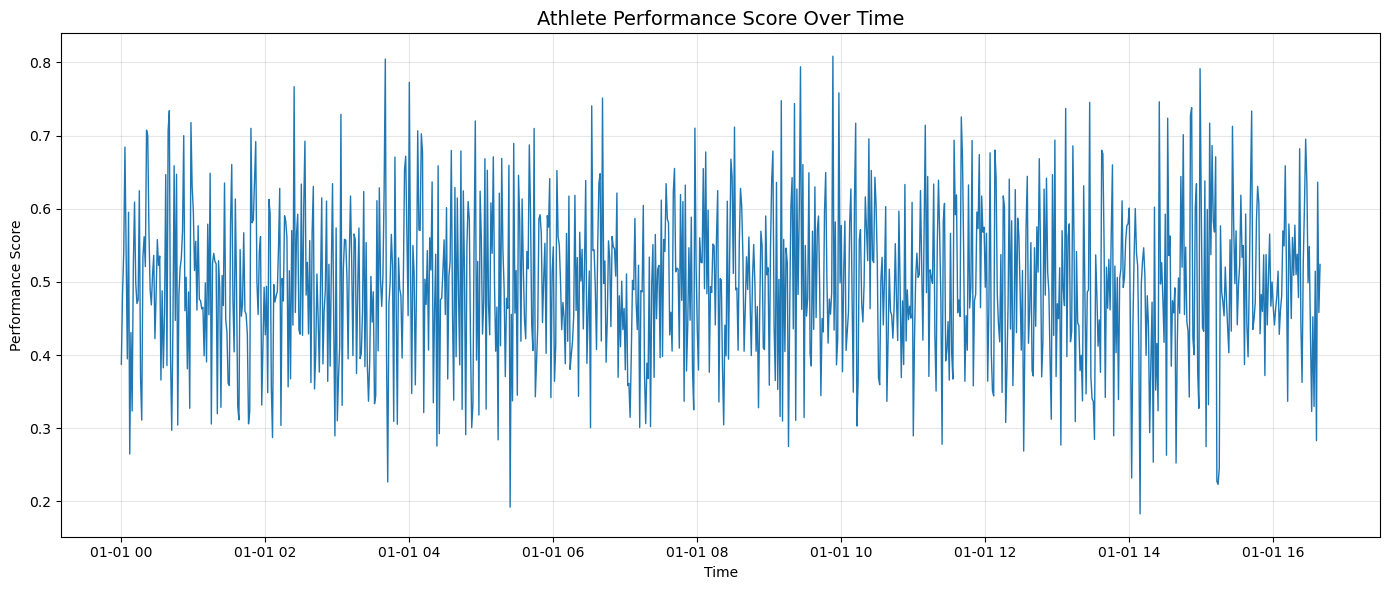

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('athlete_performance_dataset.csv')

# Parse timestamp as datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by time to ensure chronological order
df = df.sort_values('timestamp')

# Set timestamp as index for time series operations
df.set_index('timestamp', inplace=True)

# Quick summary
print("Data shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
print("\nTarget statistics (performance_score):")
print(df['performance_score'].describe())

# Visualize the time series
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['performance_score'], linewidth=1)
plt.title('Athlete Performance Score Over Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Performance Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In markdown you describe:
# - Is there a clear trend? (upward, downward, none)
# - Do you see repeating patterns (possible seasonality)?

# Check for trend/seasonality (describe what you see in markdown)

Step 2: Stationarity Test   

In [14]:
# Define a function to run the ADF test
def adf_test(series):
    # Drop NaNs to be safe
    result = adfuller(series.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    
    if result[1] <= 0.05:
        print("✓ Series is stationary (p-value <= 0.05)")
    else:
        print("✗ Series is non-stationary (p-value > 0.05)")
        print("→ Differencing may be required for some models")
    return result[1]

# Test stationarity for performance_score
p_value = adf_test(df['performance_score'])

# Optional: if non-stationary, check differenced series (for discussion)
if p_value > 0.05:
    df['performance_diff'] = df['performance_score'].diff()
    print("\nAfter differencing (first difference):")
    adf_test(df['performance_diff'])

ADF Statistic: -21.046663514142786
p-value: 0.0
Critical Values:
	1%: -3.4369259442540416
	5%: -2.8644432969122833
	10%: -2.5683158550174094
✓ Series is stationary (p-value <= 0.05)


Step 3: Seasonality Detection (Decomposition + ACF/PACF)

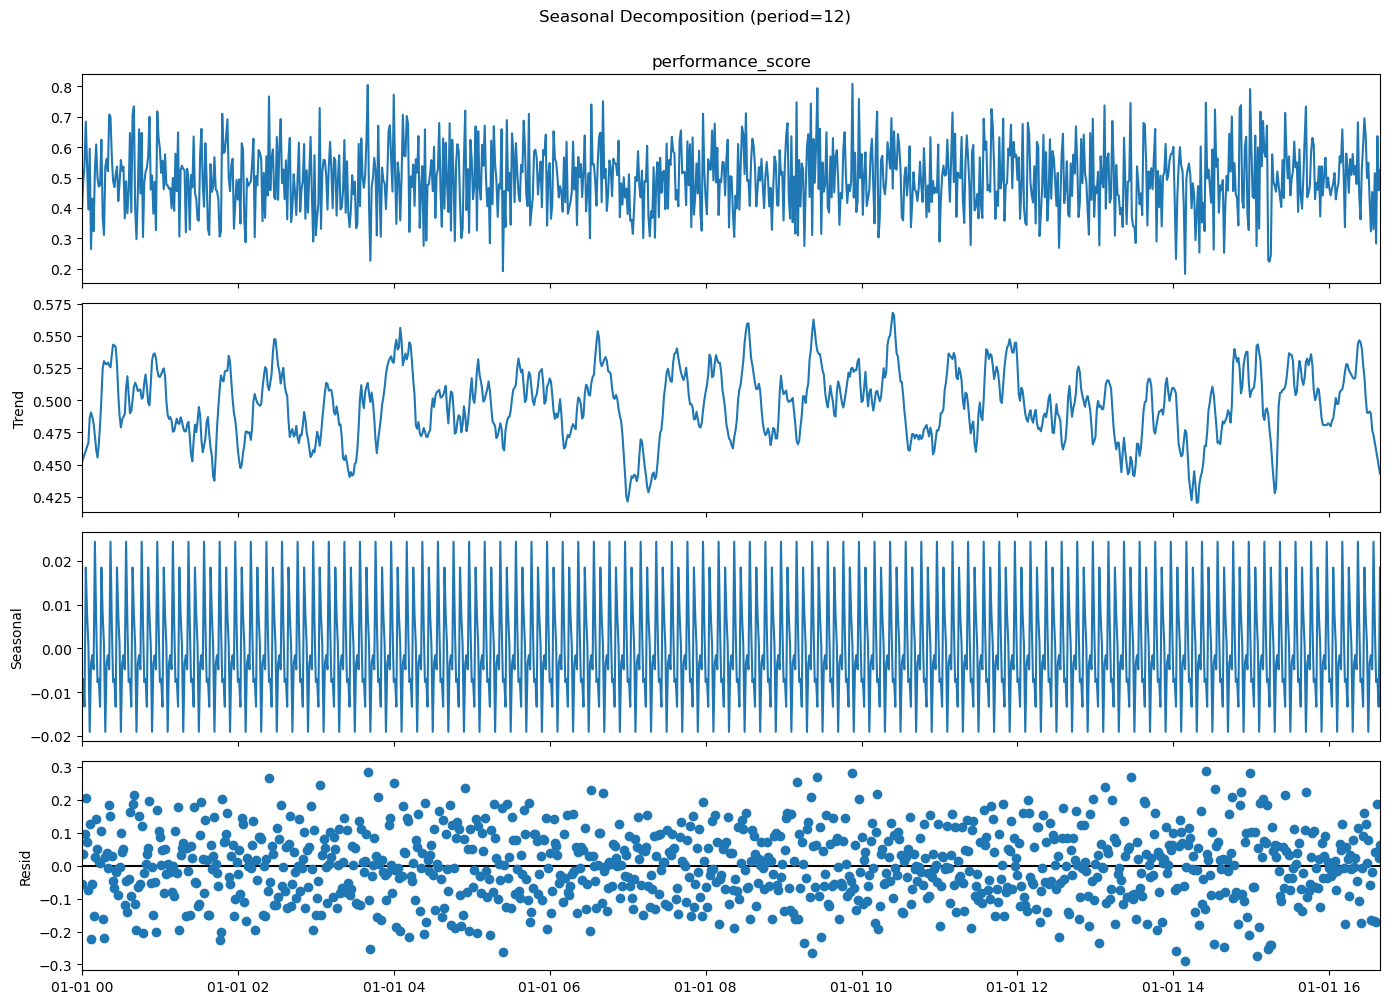

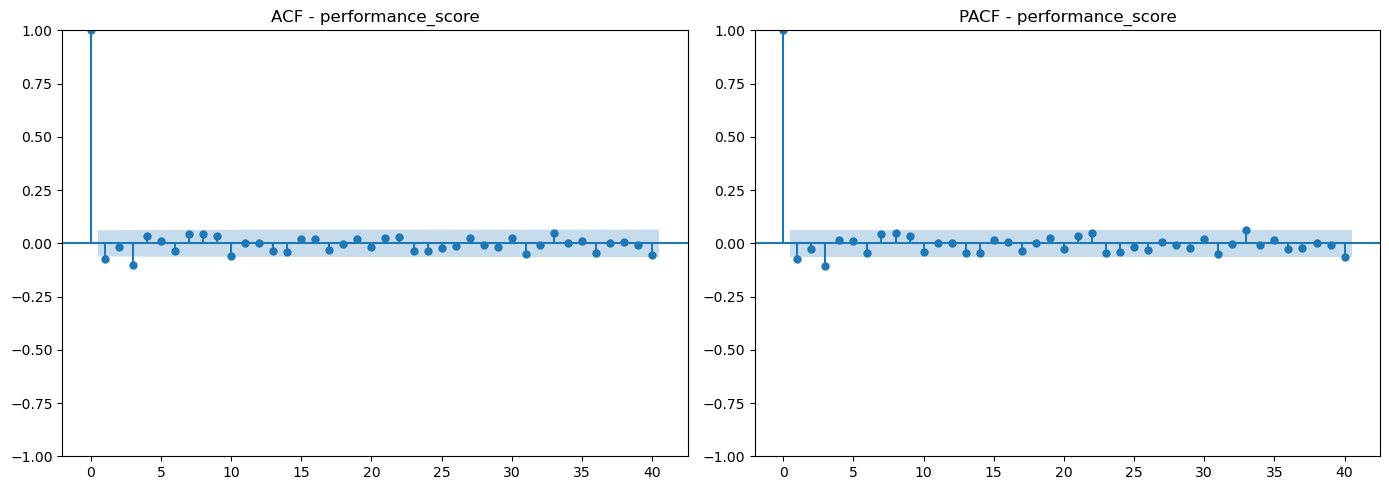

In [20]:
# =============================================================================
# Step 3: Seasonality Detection (Decomposition + ACF/PACF)
# =============================================================================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Seasonal Decomposition 
candidate_period = 12

decomp = seasonal_decompose(
    df['performance_score'],
    model='additive',
    period=candidate_period,
    extrapolate_trend='freq'
)

fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.suptitle(f'Seasonal Decomposition (period={candidate_period})', y=1.0)
plt.tight_layout()
plt.show()

# ACF and PACF plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df['performance_score'], lags=40, ax=axes[0])
axes[0].set_title('ACF - performance_score')

plot_pacf(df['performance_score'], lags=40, ax=axes[1])
axes[1].set_title('PACF - performance_score')

plt.tight_layout()
plt.show()

Step 4: Chronological Train-Test Split

In [21]:
# We use the first 80% as training and the last 20% as test.

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print("Train size:", len(train))
print("Test size:", len(test))

y_train = train['performance_score']
y_test = test['performance_score']

Train size: 800
Test size: 200


Step 5: Classical Model – Holt-Winters (Trend Only)

In [22]:

# We use trend='add' and seasonal=None because our data is not seasonal.
hw_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal=None
)

hw_fit = hw_model.fit(optimized=True)
hw_pred = hw_fit.forecast(len(test))

hw_mae = mean_absolute_error(y_test, hw_pred)
hw_rmse = np.sqrt(mean_squared_error(y_test, hw_pred))

print("Holt-Winters MAE:", hw_mae)
print("Holt-Winters RMSE:", hw_rmse)

Holt-Winters MAE: 0.09036282163121977
Holt-Winters RMSE: 0.11636323613897293


Step 6: Feature Engineering – Lag Features for ML

In [23]:
df_ml = df[['performance_score']].copy()

# Lag features
df_ml['lag_1'] = df_ml['performance_score'].shift(1)
df_ml['lag_2'] = df_ml['performance_score'].shift(2)
df_ml['lag_3'] = df_ml['performance_score'].shift(3)
df_ml['lag_7'] = df_ml['performance_score'].shift(7)

# Rolling features
df_ml['rolling_mean_3'] = df_ml['performance_score'].rolling(3).mean()
df_ml['rolling_mean_7'] = df_ml['performance_score'].rolling(7).mean()
df_ml['rolling_std_3'] = df_ml['performance_score'].rolling(3).std()

# Drop NaN rows
df_ml = df_ml.dropna()

print("Rows after lagging:", len(df_ml))

Rows after lagging: 993


Step 7: Train-Test Split for ML Dataset (Chronological)

In [24]:
split_ml = int(len(df_ml) * 0.8)

train_ml = df_ml.iloc[:split_ml]
test_ml = df_ml.iloc[split_ml:]

X_train = train_ml.drop('performance_score', axis=1)
y_train_ml = train_ml['performance_score']

X_test = test_ml.drop('performance_score', axis=1)
y_test_ml = test_ml['performance_score']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (794, 7)
X_test shape: (199, 7)


Step 8: Baseline Random Forest Model

In [25]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train_ml)

rf_pred_baseline = rf_pipeline.predict(X_test)

rf_mae_baseline = mean_absolute_error(y_test_ml, rf_pred_baseline)
rf_rmse_baseline = np.sqrt(mean_squared_error(y_test_ml, rf_pred_baseline))

print("RF Baseline MAE:", rf_mae_baseline)
print("RF Baseline RMSE:", rf_rmse_baseline)

RF Baseline MAE: 0.02941171153310502
RF Baseline RMSE: 0.04277278283546996


Step 9: Hyperparameter Tuning with GridSearchCV

In [30]:

# Define the parameter grid to search over
param_grid = {
    'rf__n_estimators': [100, 200, 300],      # number of trees
    'rf__max_depth': [10, 15, 20, None],       # max depth of each tree
    'rf__min_samples_split': [2, 5, 10],       # min samples to split a node
    'rf__min_samples_leaf': [1, 2, 4]          # min samples at a leaf node
}

# Create TimeSeriesSplit with 3 folds (respects temporal order)
tscv = TimeSeriesSplit(n_splits=3)

# Inform the user that tuning is starting
print("Starting GridSearchCV")

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf_pipeline,              # the Pipeline to tune
    param_grid=param_grid,              # parameters to search
    cv=tscv,                            # use TimeSeriesSplit for CV
    scoring='neg_mean_absolute_error',  # optimize for lowest MAE
    n_jobs=-1,                          # use all CPU cores
    verbose=1                           # show progress
)

# Fit the grid search on training data only (no leakage)
grid_search.fit(X_train, y_train_ml)

# Print the best parameters found
print("Best parameters:", grid_search.best_params_)

Starting GridSearchCV
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


Exception ignored in: <function ResourceTracker.__del__ at 0x1070d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103a15bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1060a5bc0>
Traceback (most recent call last

Step 10: Tuned Random Forest Model

In [28]:
# Get the best estimator from GridSearchCV
best_rf = grid_search.best_estimator_

# Make predictions on the test set
rf_pred_tuned = best_rf.predict(X_test)

# Calculate MAE for the tuned model
rf_mae_tuned = mean_absolute_error(y_test_ml, rf_pred_tuned)

# Calculate RMSE for the tuned model
rf_rmse_tuned = np.sqrt(mean_squared_error(y_test_ml, rf_pred_tuned))

# Print the results
print("RF Tuned MAE:", rf_mae_tuned)
print("RF Tuned RMSE:", rf_rmse_tuned)

RF Tuned MAE: 0.029405874574901084
RF Tuned RMSE: 0.042795958457259836


Step 11: Model Comparison Table

In [31]:
# Create a DataFrame to compare all three models
results = pd.DataFrame({
    'Method': [
        'Holt-Winters (Trend Only)',
        'Random Forest (Baseline)',
        'Random Forest (Tuned)'
    ],
    'MAE': [hw_mae, rf_mae_baseline, rf_mae_tuned],
    'RMSE': [hw_rmse, rf_rmse_baseline, rf_rmse_tuned]
})

# Print the comparison table
print("\nModel Comparison:")
print(results)

# Save to CSV for later use in report/slides
results.to_csv('model_comparison.csv', index=False)


Model Comparison:
                      Method       MAE      RMSE
0  Holt-Winters (Trend Only)  0.090363  0.116363
1   Random Forest (Baseline)  0.029412  0.042773
2      Random Forest (Tuned)  0.029406  0.042796


The Random Forest model achieved significantly lower error (MAE 0.0294) compared to the Holt-Winters model (MAE 0.0904), making it the better choice for forecasting athlete performance in this task.

Step 12: Error Metrics Bar Plots

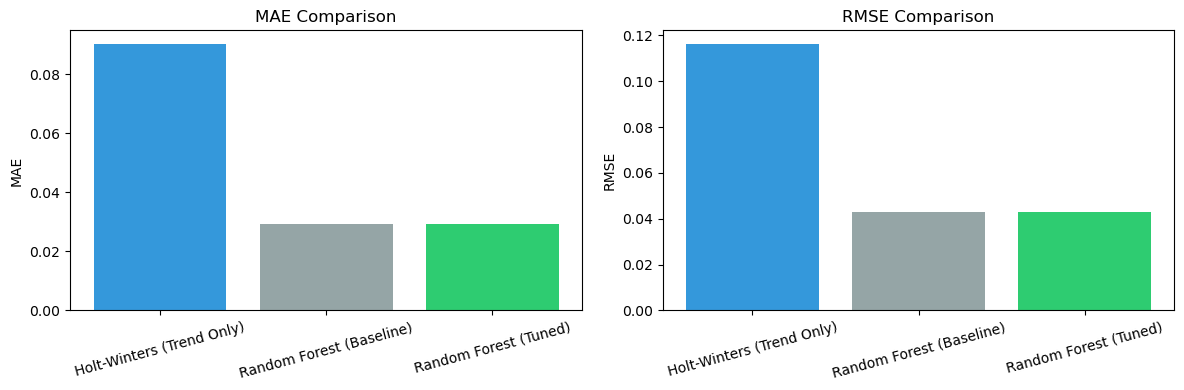

In [32]:
# Create figure with 2 subplots (MAE and RMSE side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE bar plot
axes[0].bar(results['Method'], results['MAE'], color=['#3498db', '#95a5a6', '#2ecc71'])
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)

# RMSE bar plot
axes[1].bar(results['Method'], results['RMSE'], color=['#3498db', '#95a5a6', '#2ecc71'])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Step 13: Forecast Plot – Actual vs Predictions

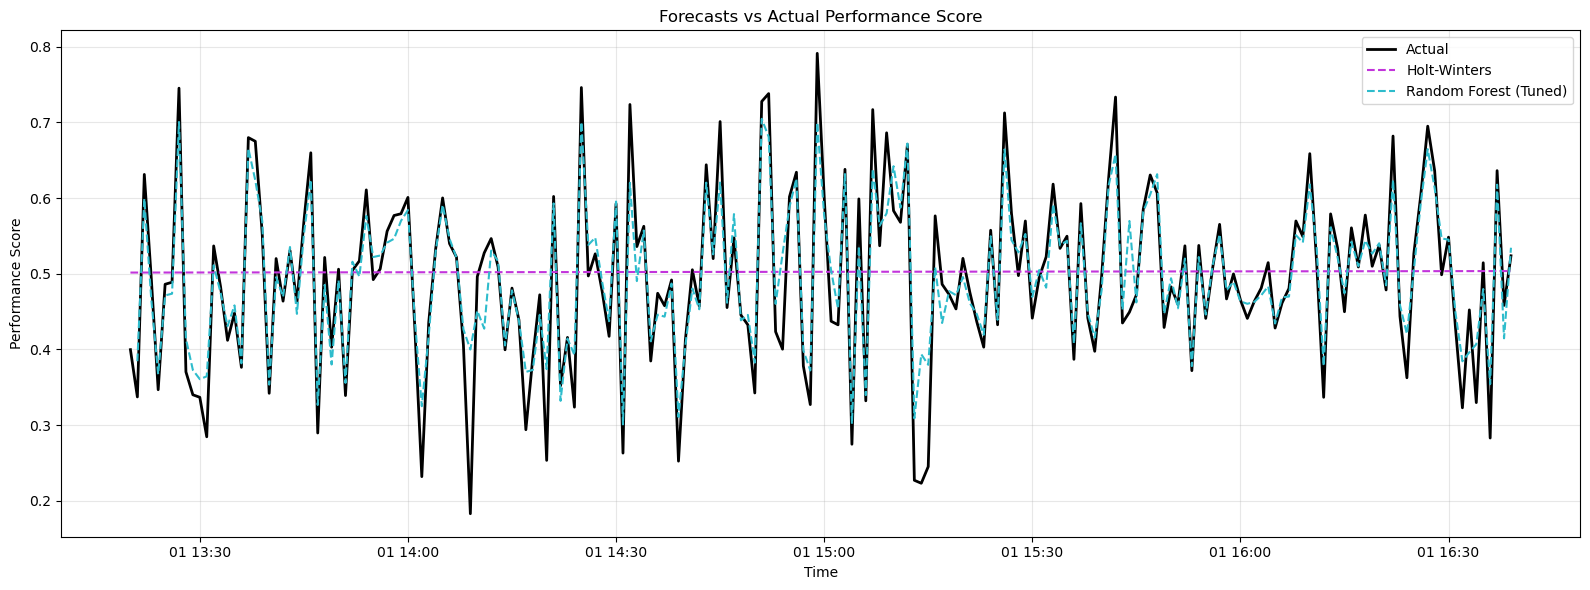

In [35]:
plt.figure(figsize=(16, 6))

# Plot actual values (black line)
plt.plot(test.index, y_test, label='Actual', color='black', linewidth=2)

# Plot Holt-Winters forecast (blue dashed line)
plt.plot(test.index, hw_pred, label='Holt-Winters', color="#c234db", linestyle='--')

# Plot RF Tuned forecast (green dashed line)
plt.plot(test_ml.index, rf_pred_tuned, label='Random Forest (Tuned)', color="#2ebccc", linestyle='--')

plt.title('Forecasts vs Actual Performance Score')
plt.xlabel('Time')
plt.ylabel('Performance Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()